╭───────────────────────────────────────────── PyCHARMM environment ──────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Field                ┃ Value                                                                                ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩ │
│ │ CGENFF RTF           │ /mmhome/boittier/home/mmml/mmml/data/charmm/top_all36_cgenff.rtf                     │ │
│ │ CGENFF PRM           │ /mmhome/boittier/home/mmml/mmml/data/charmm/par_all36_cgenff.prm                     │ │
│ │ CHARMM_HOME          │ /mmhome/boittier/home/mmml/setup/charmm                                              │ │
│ │ CHARMM_LIB_DIR       │ /mmhome/boittier/home/mmml/setup/charmm                                              │ │
│ └──────────────────────┴──────────────────────────────────────────────────────────────────────────────────────┘ │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CHARMM_HOME:  /mmhome/boittier/home/mmml/setup/charmm
CHARMM_LIB_DIR:  /mmhome/boittier/home/mmml/setup/charmm
 TITLE> *  --------------------------------------------------------------------------  *
 TITLE> *          CGENFF: TOPOLOGY FOR THE CHARMM GENERAL FORCE FIELD V. 4.6          *
 TITLE> *                    FOR SMALL MOLECULE DRUG DESIGN                            *
 TITLE> *  --------------------------------------------------------------------------  *
 TITLE> *
 TITLE> * TRIA BACKBONE CMAP (ALANINE GRID FROM PROTEIN PRM, CGENFF TYPES)
 TITLE> * REGENERATE: ./SCRIPTS/MMML-CHARMM-MPIRUN.SH PYTHON SCRIPTS/EXPORT_TRIALANINE_CGENFF_RTF.PY
 TITLE> CMAP
 PARMIO> NONBOND, HBOND lists and IMAGE atoms cleared.
 TITLE> * TRIALANINE — ACE–ALA×3–CT3 CAPPED TRI-ALANINE (CGENFF ATOM TYPES)
 TITLE> * REGENERATE: ./SCRIPTS/MMML-CHARMM-MPIRUN.SH PYTHON SCRIPTS/EXPORT_TRIALANINE_CGENFF_RTF.PY
 TITLE>  
          RESI TRIA      0.00

      ***** LEVEL  1 WARNING FROM <BILDC> *****
      ***** B

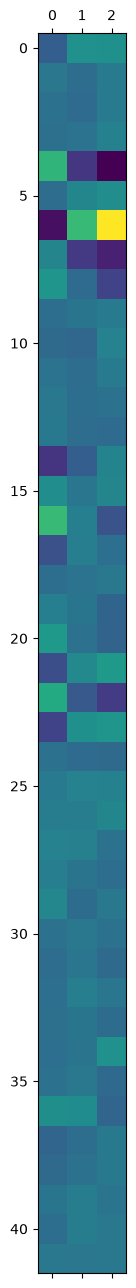

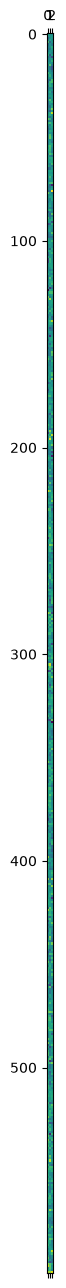

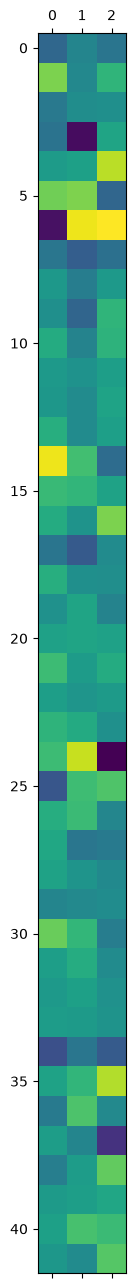

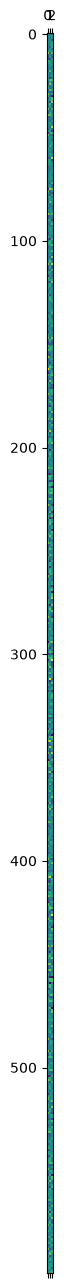

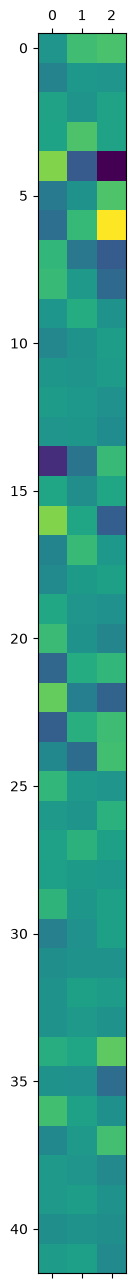

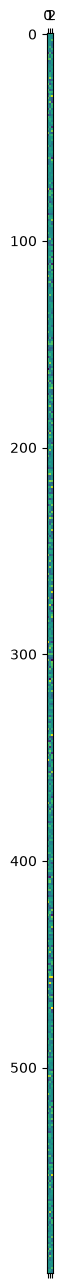

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.numpy.array(1, dtype=int)

import mmml
import ase
import numpy as np

from mmml.interfaces.pycharmmInterface.mm_system_energy import (
    CharmmNbondSettings,
    mm_system_energy_and_forces,
)

from pathlib import Path
from mmml.interfaces.pycharmmInterface.import_pycharmm import ensure_pycharmm_loaded
ensure_pycharmm_loaded()
from mmml.interfaces.pycharmmInterface.trialanine_water_box import build_trialanine_water_box_in_charmm
box = build_trialanine_water_box_in_charmm(n_waters=200, box_side_A=28.0, seed=11, workdir=Path('/tmp/tria_box'))
print(len(box.positions), box.psf_path)# ase.Atoms()
positions = box.positions
from mmml.interfaces.pycharmmInterface.import_pycharmm import CGENFF_PRM
prm = CGENFF_PRM
from mmml.interfaces.pycharmmInterface.import_pycharmm import pycharmm_loud
import pycharmm.lingo as lingo

pycharmm_loud()

from mmml.interfaces.pycharmmInterface.cgenff_bonded_reference import (
    charmm_bonded_forces_kcalmol_A,
    charmm_nonbonded_energy_components_kcalmol,
    run_charmm_nonbonded_ener_force,
    set_charmm_positions,
    setup_nonbonded_only_charmm,
)
from mmml.interfaces.pycharmmInterface.mm_system_energy import (
    load_nonbonded_system_from_charmm,
    nonbonded_energy_and_forces,
)


pos = np.asarray(positions, dtype=np.float64)
pos = np.random.uniform(-4.1, 4.1, pos.shape) + pos
set_charmm_positions(pos)

print("pos", pos)

setup_nonbonded_only_charmm()
print("setup_nonbonded_only_charmm")
# perform charmm minimization
lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 4 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
""")
# print("run_charmm_script_loud")
lingo.charmm_script("""CONStraint DROPlet !""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
""")
print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)
# save atoms to pdb file
atoms.write("atoms.pdb")

run_charmm_nonbonded_ener_force(silent=False)
charmm_terms = charmm_nonbonded_energy_components_kcalmol()
charmm_forces = charmm_bonded_forces_kcalmol_A()

# print(charmm_terms)
psf_path = box.psf_path
prm_path = CGENFF_PRM
cell = box.cell
from mmml.interfaces.pycharmmInterface.charmm_jax_energy_benchmark import _nbond_settings_from_cutoffs
nb_settings = _nbond_settings_from_cutoffs(box.nbond_cutoffs)
nbond_data = load_nonbonded_system_from_charmm(psf_path, prm_path)
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
)
jax_terms = {k: float(v) for k, v in jax_terms_raw.items()}
jax_forces_np = np.asarray(jax_forces, dtype=np.float64)

print(jax_terms)
# print(jax_forces_np)
print(charmm_terms)
# print(charmm_forces)

import matplotlib.pyplot as plt
plt.matshow(charmm_forces[:42])
plt.matshow(charmm_forces[42:])
plt.matshow(jax_forces[:42])
plt.matshow(jax_forces[42:])
plt.matshow(charmm_forces[:42] - jax_forces[:42])
plt.matshow(charmm_forces[42:] - jax_forces[42:])

# 0.1


In [2]:

lingo.charmm_script(
    """
DEFINE PHSSOLU SELE RESNAME TRIA .AND. .NOT. HYDROGEN END
DEFINE PHSWAT  SELE RESNAME TIP3 .AND. TYPE OH2 END

SHOW NSEL SELE PHSSOLU END
SHOW NSEL SELE PHSWAT END
"""
)

 SELRPN>     20 atoms have been selected out of    642
 SELRPN>    200 atoms have been selected out of    642


True

In [3]:
import pycharmm.psf as psf

print(set(psf.get_res()))
print(set(psf.get_atype()))

{'TIP3', 'TRIA'}
{'HB21', 'HB23', 'CA1', 'HN1', 'CB2', 'HB33', 'HA1', 'HN2', 'NT', 'HA2', 'O1', 'OY', 'CAT', 'HB22', 'HN3', 'HB12', 'CB1', 'HY2', 'HY3', 'HT2', 'C2', 'CA2', 'C1', 'N3', 'HB31', 'CY', 'O3', 'HT1', 'H1', 'HB32', 'N1', 'CAY', 'CA3', 'HA3', 'HY1', 'C3', 'OH2', 'N2', 'HB11', 'HNT', 'HT3', 'CB3', 'H2', 'HB13', 'O2'}


In [4]:
jax.devices()

[CudaDevice(id=0), CudaDevice(id=1)]

In [5]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [6]:
lingo.charmm_script("""ENERGY
""")


 SELECTED IMAGES ATOMS BEING CENTERED ABOUT  0.000000  0.000000  0.000000

 <MKIMAT2>: updating the image atom lists and remapping
 Transformation   Atoms  Groups  Residues  Min-Distance
    1  Z0N1N1R1 has      87      21      16        2.40
    2  Z0Z0N1R1 has     333     103      98        1.46
    3  Z0P1N1R1 has      69      23      23        4.52
    4  Z0N1Z0R1 has     330     102      97        0.00
 Total of 1461 atoms and  455 groups and  435 residues were included

 <MAKGRP> found      0 image group exclusions.

 NONBOND OPTION FLAGS: 
     ELEC     VDW      ATOMs    CDIElec  FSWItch  VATOm    VFSWIt  
     BYGRoup  NOEXtnd  NOEWald 
 CUTNB  = 13.000 CTEXNB =999.000 CTONNB =  9.000 CTOFNB = 12.278
 CGONNB =  0.000 CGOFNB = 10.000
 WMIN   =  1.500 WRNMXD =  0.500 E14FAC =  1.000 EPS    =  1.000
 NBXMOD =      5
 There are    76526 atom  pairs and      804 atom  exclusions.
 There are        0 group pairs and        7 group exclusions.
 Generating nonbond list with Exclusion 

True

In [7]:
lingo.charmm_script("""CONStraint DROPlet !FORC 0.001 ! [FORCe real] [EXPOnent integer] [NOMAss]""")

 DROPLET CONSTRAINTS REMOVED


True

In [8]:
# print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet !""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 1000
""")
lingo.charmm_script("MINI SD 1000")
print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)
# save atoms to pdb file
atoms.write("atoms.pdb")


 SELECTED IMAGES ATOMS BEING CENTERED ABOUT  0.000000  0.000000  0.000000

 <MKIMAT2>: updating the image atom lists and remapping
 Transformation   Atoms  Groups  Residues  Min-Distance
    1  Z0N1N1R1 has      90      22      17        2.26
    2  Z0Z0N1R1 has     330     102      97        1.03
    3  Z0P1N1R1 has      66      22      22        4.25
    4  Z0N1Z0R1 has     327     101      96        0.00
 Total of 1455 atoms and  453 groups and  433 residues were included

 <MAKGRP> found      0 image group exclusions.

 NONBOND OPTION FLAGS: 
     ELEC     VDW      ATOMs    CDIElec  FSWItch  VATOm    VFSWIt  
     BYGRoup  NOEXtnd  NOEWald 
 CUTNB  = 13.000 CTEXNB =999.000 CTONNB =  9.000 CTOFNB = 12.278
 CGONNB =  0.000 CGOFNB = 10.000
 WMIN   =  1.500 WRNMXD =  0.500 E14FAC =  1.000 EPS    =  1.000
 NBXMOD =      5
 There are    76473 atom  pairs and      804 atom  exclusions.
 There are        0 group pairs and        7 group exclusions.
 Generating nonbond list with Exclusion 

In [9]:
molecule_id = np.empty(len(atoms), dtype=np.int32)

# Trialanine
molecule_id[:42] = 0

# 50 water molecules
for mol_id, start in enumerate(
    range(42, len(atoms), 3),
    start=1,
):
    molecule_id[start:start + 3] = mol_id

assert np.all(molecule_id[:42] == 0)

for start in range(42, len(atoms), 3):
    assert len(set(molecule_id[start:start + 3])) == 1

# assert molecule_id.max() == 50

In [10]:
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [11]:
full_terms, _ = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
)

inter_terms, _ = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [12]:
print("full:", {k: float(v) for k, v in full_terms.items()})
print("inter:", {k: float(v) for k, v in inter_terms.items()})

full: {'vdw': 359.92342556530315, 'elec': -2227.059296243184, 'total': -1867.1358706778806}
inter: {'vdw': 363.28846521327466, 'elec': -2233.0509088231092, 'total': -1869.7624436098345}


In [13]:
charmm_terms

{'vdw': 498.9236147573758,
 'elec': -1896.6855831603639,
 'total': -1397.761968402988}

In [14]:
jax_terms_raw

{'vdw': Array(363.28846521, dtype=float64),
 'elec': Array(-2233.05090882, dtype=float64),
 'total': Array(-1869.76244361, dtype=float64)}

In [15]:
nb_settings

CharmmNbondSettings(cutnb=13.0, ctonnb=9.0, ctofnb=12.277777777777777, eps=1.0, e14fac=1.0, vdw14fac=0.0, elec_switch='fswitch', vdw_switch='vfswitch')

# 0.2


In [16]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [17]:
CKPT_PATH = "params_aaa_long_2026-07-04_22-30-27.json"

In [18]:
from mmml.interfaces.calculators.simple_inference import create_calculator_from_checkpoint

In [19]:
calc = create_calculator_from_checkpoint(CKPT_PATH)

✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']


In [20]:
calc

<mmml.models.physnetjax.physnetjax.calc.helper_mlp.get_ase_calc.<locals>.MessagePassingCalculator at 0x14d29d846f90>

In [21]:
prot = atoms[:42]
prot.get_atomic_numbers()
_pos = prot.get_positions()
prot.set_positions(_pos - _pos.T.mean(axis=-1))

In [22]:
water = atoms[42:]
water.get_atomic_numbers()
_pos = water.get_positions()
# water.set_positions(_pos - _pos.T.mean(axis=-1))

In [23]:
ase.visualize.view(prot, viewer="x3d")

In [24]:
ase.visualize.view(water, viewer="x3d")

In [25]:
ase.visualize.view(water + prot, viewer="x3d")

In [26]:
prot_water = prot + water

In [27]:
prot.calc = calc
water.calc = calc
prot_water.calc = calc

In [28]:
prot.get_potential_energy(), water.get_potential_energy(), prot_water.get_potential_energy()

(Array(-163.6487509, dtype=float64),
 Array(-2191.15437222, dtype=float64),
 Array(-2355.35132682, dtype=float64))

In [29]:
prot.get_forces()

array([[-1.97364328e-01, -2.13367204e-01,  1.07563115e+00],
       [ 1.43115342e+00, -3.97478631e-01, -4.25281719e-01],
       [-4.66731353e-01,  8.69322085e-01, -1.05441071e+00],
       [-2.52269049e-01, -4.90355125e-01,  3.00804576e-01],
       [ 4.33259585e-01,  8.81938080e-01, -7.03280257e-01],
       [-1.18683924e+00, -6.68558887e-01, -6.03406070e-02],
       [ 8.99142668e-01,  6.94102272e-01,  1.51653639e+00],
       [-6.08595119e-03, -9.66506479e-01, -1.16611303e+00],
       [ 1.30580685e-01,  1.55209958e+00,  1.21855985e-01],
       [ 3.32875263e-03, -3.24857457e-01,  2.08878517e-01],
       [-2.97720792e-01, -3.24623308e-01,  3.88370229e-01],
       [ 3.91835005e-01, -5.11477468e-01, -2.91459601e-01],
       [-8.99459336e-01, -9.27877024e-02, -2.27135672e-01],
       [ 3.91668987e-01,  6.61324367e-01, -2.95199379e-01],
       [-1.74668665e-01, -1.40241623e+00,  1.51625041e+00],
       [-1.07478039e+00, -8.66833914e-01, -4.37521519e-01],
       [ 3.06919820e-01,  2.24487145e+00

In [30]:
from ase.optimize import QuasiNewton

# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(prot, trajectory='prot_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=0.3)


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:26:54     -163.648751       3.5115


/mmhome/boittier/home/mmml/.venv/lib/python3.13/site-packages/ase/io/trajectory.py:215: UserWarning: Skipping "output" info.
  warnings.warn(f'Skipping "{key}" info.')


BFGSLineSearch:    1[  2] 11:26:55     -164.183754       1.9365
BFGSLineSearch:    2[  4] 11:26:55     -164.386349       1.4212
BFGSLineSearch:    3[  6] 11:26:55     -164.469811       0.7662
BFGSLineSearch:    4[  8] 11:26:55     -164.535300       0.5656
BFGSLineSearch:    5[ 10] 11:26:55     -164.591653       0.7924
BFGSLineSearch:    6[ 12] 11:26:55     -164.644126       0.5653
BFGSLineSearch:    7[ 14] 11:26:55     -164.680736       0.6323
BFGSLineSearch:    8[ 16] 11:26:55     -164.700174       0.5963
BFGSLineSearch:    9[ 18] 11:26:55     -164.734421       0.4520
BFGSLineSearch:   10[ 20] 11:26:55     -164.765430       0.3927
BFGSLineSearch:   11[ 22] 11:26:55     -164.791251       0.5765
BFGSLineSearch:   12[ 24] 11:26:55     -164.816400       0.6078
BFGSLineSearch:   13[ 26] 11:26:55     -164.835133       0.4348
BFGSLineSearch:   14[ 28] 11:26:55     -164.856951       0.3478
BFGSLineSearch:   15[ 30] 11:26:55     -164.876119       0.4609
BFGSLineSearch:   16[ 32] 11:26:55     -

np.True_

In [31]:
ase.visualize.view(prot, viewer="x3d")

In [32]:
# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(water, trajectory='water_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=5)
ase.visualize.view(water, viewer="x3d")

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:27:00    -2191.154372       3.5340


In [33]:
prot_water = prot + water 
prot_water.calc = calc

In [34]:
# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(prot_water, trajectory='prot_water_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=3)


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:27:05    -2356.618735       3.5339
BFGSLineSearch:    1[  1] 11:27:05    -2371.322796      14.1903
BFGSLineSearch:    2[  3] 11:27:05    -2409.283400      13.2626
BFGSLineSearch:    3[  4] 11:27:05    -2430.704104      20.1195
BFGSLineSearch:    4[  6] 11:27:05    -2456.578343      18.6360
BFGSLineSearch:    5[  7] 11:27:06    -2485.612019      21.2800
BFGSLineSearch:    6[  8] 11:27:06    -2521.681473      24.3086
BFGSLineSearch:    7[  9] 11:27:06    -2562.111246      25.3687
BFGSLineSearch:    8[ 10] 11:27:06    -2606.784088      26.2690
BFGSLineSearch:    9[ 11] 11:27:06    -2668.940015      17.5991
BFGSLineSearch:   10[ 12] 11:27:06    -2715.445491      24.7587
BFGSLineSearch:   11[ 13] 11:27:06    -2758.026150      19.7832
BFGSLineSearch:   12[ 14] 11:27:06    -2797.950399      30.9848
BFGSLineSearch:   13[ 15] 11:27:06    -2833.864610      18.1653
BFGSLineSearch:   14[ 16] 11:27:06    -

KeyboardInterrupt: 

In [35]:
ase.visualize.view(prot_water, viewer="x3d")

In [36]:
z = get_Z_from_psf()


In [37]:
# pos = prot_water.get_positions()

# set_charmm_positions(pos)
pos = prot_water.get_positions()
print("pos", pos)

setup_nonbonded_only_charmm()
print("setup_nonbonded_only_charmm")
# perform charmm minimization
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
    MINI ABNR 10000
""")
print("run_charmm_script_loud")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)

# save atoms to pdb file
atoms.write("atoms.pdb")

pos [[ -2.22625794  -1.86166928   1.60243827]
 [ -3.30046295  -1.75777323   1.42301746]
 [ -2.12368202  -2.41663972   2.57865751]
 ...
 [  7.86139785  -7.20399805  -7.3271921 ]
 [  7.24562636 -12.21408808  -6.25314257]
 [  7.89128927  -8.15064971  -4.89188209]]
setup_nonbonded_only_charmm
run_charmm_script_loud
pos [[ 9.59918386  8.6563538  12.43831808]
 [ 8.55267132  9.01997452 12.35773698]
 [ 9.7266204   8.14258299 13.41564443]
 ...
 [ 8.64172912 -3.954437   -8.59423714]
 [ 9.07997788 -4.57310596 -7.97887531]
 [ 8.41254172 -3.22761149 -7.97727889]]
z [np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1)

In [38]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [39]:
box.nbond_cutoffs

PbcNbondCutoffs(cubic_box_side_A=28.0, cutnb=13.0, cutim=13.0, ctonnb=9.0, ctofnb=12.277777777777777, ctexnb=13.0)

In [40]:
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)

# save atoms to pdb file
atoms.write("atoms.pdb")

run_charmm_nonbonded_ener_force(silent=False)
charmm_terms = charmm_nonbonded_energy_components_kcalmol()
charmm_forces = charmm_bonded_forces_kcalmol_A()

# print(charmm_terms)
psf_path = box.psf_path
prm_path = CGENFF_PRM
cell = box.cell
from mmml.interfaces.pycharmmInterface.charmm_jax_energy_benchmark import _nbond_settings_from_cutoffs
nb_settings = _nbond_settings_from_cutoffs(box.nbond_cutoffs)
nbond_data = load_nonbonded_system_from_charmm(psf_path, prm_path)
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
        molecule_id=molecule_id,
)
jax_terms = {k: float(v) for k, v in jax_terms_raw.items()}
jax_forces_np = np.asarray(jax_forces, dtype=np.float64)

print(jax_terms)
# print(jax_forces_np)
print(charmm_terms)
# print(charmm_forces)

pos [[ 9.59918386  8.6563538  12.43831808]
 [ 8.55267132  9.01997452 12.35773698]
 [ 9.7266204   8.14258299 13.41564443]
 ...
 [ 8.64172912 -3.954437   -8.59423714]
 [ 9.07997788 -4.57310596 -7.97887531]
 [ 8.41254172 -3.22761149 -7.97727889]]
z [np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8),

In [41]:
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [42]:
jax_terms_raw

{'vdw': Array(405.88522427, dtype=float64),
 'elec': Array(-2636.48647733, dtype=float64),
 'total': Array(-2230.60125306, dtype=float64)}

In [43]:
from ase.calculators.calculator import Calculator

In [44]:
import copy
import numpy as np

from ase.calculators.calculator import Calculator, all_changes
from ase.calculators.mixing import SumCalculator
from ase.units import kcal, mol

class MolecularPhysNetCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        peptide_calc,
        water_calc,
        peptide_indices,
        water_indices,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.peptide_calc = peptide_calc
        self.water_calc = water_calc

        self.peptide_indices = np.asarray(peptide_indices, dtype=int)
        self.water_indices = [
            np.asarray(idx, dtype=int)
            for idx in water_indices
        ]

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        energy = 0.0
        forces = np.zeros((len(atoms), 3), dtype=np.float64)

        # Trialanine
        peptide = atoms[self.peptide_indices].copy()
        peptide.pbc = False
        peptide.calc = self.peptide_calc

        energy += peptide.get_potential_energy()
        forces[self.peptide_indices] += peptide.get_forces()

        # Waters
        for idx in self.water_indices:
            water = atoms[idx].copy()
            water.pbc = False
            water.calc = self.water_calc

            energy += water.get_potential_energy()
            forces[idx] += water.get_forces()

        self.results = {
            "energy": float(energy),
            "forces": forces,
        }

In [46]:
atomic_numbers = z
z = np.asarray(atoms.numbers)

n_trialanine = 42

assert (len(z) - n_trialanine) % 3 == 0
assert np.all(
    z[n_trialanine:].reshape(-1, 3)
    == np.array([8, 1, 1])
)

monomer_indices = [np.arange(n_trialanine)]

monomer_indices.extend(
    np.arange(i, i + 3)
    for i in range(n_trialanine, len(atoms), 3)
)

In [47]:
calc = create_calculator_from_checkpoint(CKPT_PATH)

✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']


In [48]:
class MonomerSumCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        monomer_indices,
        calculators=None,
        calculator_factory=None,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.monomer_indices = [
            np.asarray(indices, dtype=int)
            for indices in monomer_indices
        ]

        if calculators is not None:
            if len(calculators) != len(self.monomer_indices):
                raise ValueError(
                    "Need exactly one calculator per monomer."
                )
            self.calculators = list(calculators)

        elif calculator_factory is not None:
            self.calculators = [
                calculator_factory()
                for _ in self.monomer_indices
            ]

        else:
            raise ValueError(
                "Provide calculators or calculator_factory."
            )

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        energy = 0.0
        forces = np.zeros((len(atoms), 3), dtype=np.float64)

        for indices, calc in zip(
            self.monomer_indices,
            self.calculators,
        ):
            monomer = atoms[indices].copy()

            # Usually desirable for a molecular ML potential:
            monomer.pbc = False

            monomer.calc = calc

            energy += monomer.get_potential_energy()
            forces[indices] += monomer.get_forces()

        self.results = {
            "energy": float(energy),
            "forces": forces,
        }

In [49]:
physnet_monomers = MonomerSumCalculator(
    monomer_indices=monomer_indices,
    calculator_factory=lambda: create_calculator_from_checkpoint(CKPT_PATH),
)

✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /mmhome/boittier/home/mmml/examples/params_a

In [50]:
factor = 0.0433641153087705  # eV per kcal/mol

class JAXIntermolecularCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        nbond_data,
        nb_settings,
        energy_factor=1.0 * factor,
        force_factor=1.0 * factor,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.nbond_data = nbond_data
        self.nb_settings = nb_settings
        self.energy_factor = float(energy_factor)
        self.force_factor = float(force_factor)

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        pos = np.asarray(
            atoms.get_positions(),
            dtype=np.float64,
        )
        cell = np.asarray(
            atoms.cell.array,
            dtype=np.float64,
        )

        terms_raw, forces = nonbonded_energy_and_forces(
            pos,
            self.nbond_data,
            cell,
            self.nb_settings,
        )

        terms = {
            key: float(value)
            for key, value in terms_raw.items()
        }

        # Replace this with the exact total key used by your function.
        if "total" in terms:
            energy = terms["total"]
        else:
            energy = sum(terms.values())

        self.results = {
            "energy": energy * self.energy_factor,
            "forces": (
                np.asarray(forces, dtype=np.float64)
                * self.force_factor
            ),
        }

        # Optional diagnostic information.
        self.results["jax_terms"] = terms

# 0.3

In [51]:
atoms.set_cell(box.cell)
atoms.set_pbc(True)

jax_inter = JAXIntermolecularCalculator(
    nbond_data=nbond_data,
    nb_settings=nb_settings,
)

atoms.calc = SumCalculator([
    physnet_monomers,
    jax_inter,
])

In [52]:
energy = atoms.get_potential_energy()
forces = atoms.get_forces()

In [53]:
energy

-2260.012190005791

In [54]:
forces

array([[-0.36633185,  0.59376872,  0.4748955 ],
       [ 1.34961639, -0.87498646, -0.02125913],
       [-0.23082968,  0.71142391, -1.32416105],
       ...,
       [ 0.03838893,  0.00573176,  0.12303237],
       [ 0.6496729 , -1.35001774, -0.10604807],
       [-0.67878745,  1.32914131, -0.0912847 ]], shape=(642, 3))

In [55]:
ase.visualize.view(atoms, viewer="x3d")

In [56]:
# # 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
# dyn = QuasiNewton(atoms, trajectory='prot_sum_calc_water_min.traj')
# # 4. Run minimization until max force on any atom < 0.05 eV/Å
# dyn.run(fmax=3)
from ase.optimize import FIRE
# 3. Initialize the FIRE optimizer
opt = FIRE(atoms, 
           # logfile='fire_log.txt'
          )

# 4. Run the minimization
# fmax represents the maximum force allowed (in eV/Angstrom)
opt.run(fmax=.5)

      Step     Time          Energy          fmax
FIRE:    0 11:30:43    -2260.012190        4.616254
FIRE:    1 11:30:46    -2264.916352        1.493143
FIRE:    2 11:30:49    -2267.539000        1.802356
FIRE:    3 11:30:53    -2268.219401        1.780070
FIRE:    4 11:30:56    -2268.319595        1.399742
FIRE:    5 11:30:59    -2268.444792        0.713933
FIRE:    6 11:31:02    -2268.512307        1.077626
FIRE:    7 11:31:05    -2268.512663        1.377224
FIRE:    8 11:31:09    -2268.519933        1.276996
FIRE:    9 11:31:12    -2268.533065        1.085286
FIRE:   10 11:31:15    -2268.549621        0.820773
FIRE:   11 11:31:16    -2268.566819        0.515652
FIRE:   12 11:31:19    -2268.582344        0.399164


np.True_

In [57]:
ase.visualize.view(atoms, viewer="x3d")

In [ ]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units
from ase.md.verlet import VelocityVerlet
from ase import Atoms

def printenergy(atoms: Atoms) -> None:
    """Function to print the potential, kinetic and total energy"""
    epot = atoms.get_potential_energy() / len(atoms)
    ekin = atoms.get_kinetic_energy() / len(atoms)
    temperature = ekin / (1.5 * units.kB)

    print(f'Energy per atom: Epot = {epot:.3f}eV  Ekin = {ekin:.3f}eV '
          f'(T={temperature:3.0f}K)  Etot = {epot+ekin:.3f}eV')

from ase import units
from ase.md.verlet import VelocityVerlet
# Set the momenta corresponding to T=300K
MaxwellBoltzmannDistribution(atoms, temperature_K=300)
dyn = VelocityVerlet(atoms, 0.5 * units.fs,     trajectory="md.traj")
# print starting energies
printenergy(atoms)
# print energies as system evolves
for i in range(10):
    dyn.run(1000)
    printenergy(atoms)
    MaxwellBoltzmannDistribution(atoms, temperature_K=300)
# dyn = VelocityVerlet(cu_cube, 5 * units.fs)

/tmp/ipykernel_1138912/494526868.py:18: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(atoms, temperature_K=300)


Energy per atom: Epot = -3.534eV  Ekin = 0.037eV (T=288K)  Etot = -3.496eV


In [ ]:
ase.visualize.view(atoms, viewer="x3d")

In [ ]:
import pycharmm.cons_harm as cons_harm
# cons_harm?

In [ ]:
# command = """
# MMFP
# BHEL SELE SEGID TRIA .AND. .NOT. HYDROGEN END
# SHEL SELE RESNAME TIP3 .AND. TYPE OH2 END -
#      DRSH 8.0 RWEL 0.25 PFINAL 1.0 -
#      SCO 0 RELA 0.00001 UPDF 10 -
#      CHFR 1000 SPACE 1000000 CHCO 0.00001 -
#      FOCO1 3.0 FOCO2 3.0 CUT 2.0
# END
# """

In [ ]:
# run_charmm_script_loud(command)

In [ ]:
lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")

In [ ]:
# pos = atoms.get_positions()

# set_charmm_positions(pos)
atoms_tracker = []
# print("pos", pos)
for i in range(100):
    # setup_nonbonded_only_charmm()
    print("setup_nonbonded_only_charmm")
    # perform charmm minimization
    from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
    run_charmm_script_loud("""
    MINI SD 10000
    MINI ABNR 10000
    """)
    
    # print("atoms", atoms)
    
    # save atoms to pdb file
    
    import sys
    import os
    
    os.environ['CHARMM_LIB_DIR'] = '/Users/ericboittier/mmml/setup/charmm'
    
    import pycharmm
    import pycharmm.dynamics as charm_dyn
    
    # kw = {"start": True, "restart": False, "iasvel": 1, "iunrea": 88}
    dyn = pycharmm.DynamicsScript(lang=True, restart=False, nstep=50000, timest=0.005,
                            firstt=298.0, finalt=298.0, tbath=298.0, tstruc=298.0,
                            teminc=0.0, twindh=0.0, twindl=0.0,
                            iasors=0, iasvel=1, ichecw=0, iscale=0, iscvel=0,
                            echeck=-1.0, nsavc=10, nsavv=0, ntrfrq=1000, isvfrq=1000,
                            iprfrq=50, nprint=10, ihtfrq=0, ieqfrq=1,
                            ilbfrq=0)
    dyn.run()
    
    # print("run_charmm_script_loud")
    from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
    pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
    # print("pos", pos)
    from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
    z = get_Z_from_psf()
    # print("z", z)
    atoms_ = ase.Atoms(z, pos)
    atoms_.write(f"atoms_{i}.pdb")
    atoms_tracker.append(atoms_)

In [ ]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()